# Module 1 - Revisiting Basics of Keplerian Motion

...or introduction to orbital mechanics if this is your first rodeo ;)

This module revisits the fundamentals of unperturbed Keplerian spacecraft motion. The material is presented as a review and therefore moves quickly, with the assumption that the basic concepts of particle kinematics and orbital mechanics have been encountered before.

The first part of the module returns to particle kinematics and the description of motion using position, velocity, and acceleration vectors. This provides the mathematical foundation needed to describe spacecraft motion consistently before introducing the orbital dynamics.

The remainder of the module reviews the classical two-body problem, beginning with conic sections and progressing to Kepler's equation and the classical orbital elements. Together, these concepts provide the baseline description of ideal spacecraft motion before perturbations and relative-motion effects are introduced later in the course.

**<ins>Learning Objectives</ins>**

- Review the fundamental relationships used in particle kinematics.
- Describe Keplerian orbits using conic sections.
- Apply Kepler's equation to determine spacecraft position as a function of time.
- Describe an orbit using the classical orbital elements.
- Establish the two-body Keplerian model that will be used as the reference for later relative-motion analysis.

**<ins>Content</ins>**
- Particle kinematics fundamentals
- Conic sections and Keplerian orbits
- Kepler's equation and orbital time propagation
- Classical orbital elements

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Any
from typing import cast

from numpy.typing import NDArray

import sympy as sp

from sympy.physics.vector import Vector
from sympy.physics.vector import ReferenceFrame
from sympy.physics.vector import dynamicsymbols
from IPython.display import display, Math

import plotly
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

from dataclasses import dataclass

# 1.1 - Fundamentals of Particle Kinematics

## 1.1.1 - Vectors, Reference Frames, and Coordinate Representation

Before describing motion, we first need to be precise about **what is being measured** and **relative to what it is being measured**.

A **scalar** is a physical quantity that can be completely described by a single numerical value and its associated units. Scalars have magnitude but no direction. Examples include mass, temperature, time, and distance.

A **vector**, on the other hand, contains both magnitude and direction. Position, velocity, acceleration, and force are all vector quantities.

Consider the statement:

> An object is located $5\,\text{m}$ away.

This statement is incomplete if we want to describe the object's position. We must also ask:

- $5\,\text{m}$ away from **what point**?
- In **what direction**?

The reference point defines the **origin** from which the position is measured. Together with a set of basis directions, this defines a **reference frame**.

**<ins>Reference Frames and Coordinate Representation</ins>**

Consider a reference frame $N$ with three orthogonal basis vectors

$$
\mathcal{N} =
\left\{
\hat{\mathbf n}_1,
\hat{\mathbf n}_2,
\hat{\mathbf n}_3
\right\}.
$$

A physical vector $\mathbf r$ can be constructed from these basis vectors as

$$
\mathbf r = r_1\hat{\mathbf n}_1 + r_2\hat{\mathbf n}_2 + r_3\hat{\mathbf n}_3.
$$

The scalars $r_1$, $r_2$, and $r_3$ tell us how much of $\mathbf r$ lies along each basis direction. These values are called the **components** of the vector in frame $N$.

We can collect these components into a column vector,

$$
[\mathbf r]_N =
\begin{bmatrix}
r_1\\
r_2\\
r_3
\end{bmatrix}.
$$

This is the **coordinate representation** of $\mathbf r$ in frame $N$.

It is important to distinguish between the two:

$$
\boxed{
\mathbf r
\quad\text{is the geometric vector}
}
$$

while

$$
\boxed{
[\mathbf r]_N
\quad\text{is its numerical representation in frame }N
}
$$

If another reference frame $B$ is used, the same physical vector may have a different coordinate representation,

$$
[\mathbf r]_B \neq [\mathbf r]_N,
$$

even though $\mathbf r$ itself has not changed.

In numerical work, we usually store and manipulate these **vector components** and transform them from one frame to another using a **Direction Cosine Matrices (DCMs)**,

$$
[\mathbf r]_B = [BN] [\mathbf r]_N
$$

where $[BN]$ is the DCM decribing the orientation of the $B$-frame to the $N$-frame and provides a means to map a vector in $N$-frame to the $B$-frame. Please refer to the course notes in the first specialization, specifically the first course, where an extensive treatment is done to describe DCMs and the equivalent attitude representations to decribe orientation and frame conversions.

**<ins>Inertial Reference Frames</ins>**

Newton's laws take their simplest form when motion is described relative to an **inertial reference frame**.

An inertial frame is a frame whose origin is not accelerating and whose axes are not rotating relative to inertial space. A frame may translate at constant velocity and still be inertial.

In such a frame, the acceleration obtained by differentiating the position vector twice corresponds directly to the acceleration used in Newton's second law,

$$
\mathbf F = m\ddot{\mathbf r}.
$$

If the reference frame itself accelerates or rotates, additional kinematic terms appear. Understanding how vector derivatives change between different reference frames will therefore become important when describing spacecraft motion.

In [2]:
# ---------------------------------------------------------------------------------------
# Vector and frame notation
#
# In numerical code, explicitly include the reference frame in the variable name:
#
#     <vector>_<frame> = np.array([...])
#
# Example:
#
#     r_N
#
# means:
#     "the components of the geometric vector r expressed in reference frame N."
#
# For direction cosine matrices:
#
#     C_BN
#
# maps vector components from frame N into frame B:
#
#     r_B = C_BN @ r_N
#
# Unless explicitly stated otherwise, coordinate transformations in this notebook
# are PASSIVE:
#
#     - The physical vector does not rotate.
#     - The reference frame / basis changes.
#     - Only the coordinate representation changes.
#
# Active rotations will be explicitly identified as rotations of the geometric vector.
# ---------------------------------------------------------------------------------------

# Vector expressed in reference frame N
r_N = np.array([4.0, 3.0])

# Frame B is rotated counter-clockwise relative to frame N
theta = np.deg2rad(35.0)

c = np.cos(theta)
s = np.sin(theta)

# Passive transformation: N-components -> B-components
C_BN = np.array([
    [ c,  s],
    [-s,  c]
])

r_B = C_BN @ r_N

# Active rotation: rotate the physical vector by +theta while keeping frame N fixed
R_theta = np.array([
    [c, -s],
    [s,  c]
])

r_rotated_N = R_theta @ r_N

print(f"Vector components in frame N: {r_N}")
print(f"Vector components in frame B: {r_B}")
print(f"Actively rotated vector in frame N: {r_rotated_N}")

print(f"\nMagnitude in frame N: {np.linalg.norm(r_N):.3f}")
print(f"Magnitude in frame B: {np.linalg.norm(r_B):.3f}")
print(f"Magnitude after active rotation: {np.linalg.norm(r_rotated_N):.3f}")

Vector components in frame N: [4. 3.]
Vector components in frame B: [4.99733749 0.16315039]
Actively rotated vector in frame N: [1.55587887 4.75176188]

Magnitude in frame N: 5.000
Magnitude in frame B: 5.000
Magnitude after active rotation: 5.000


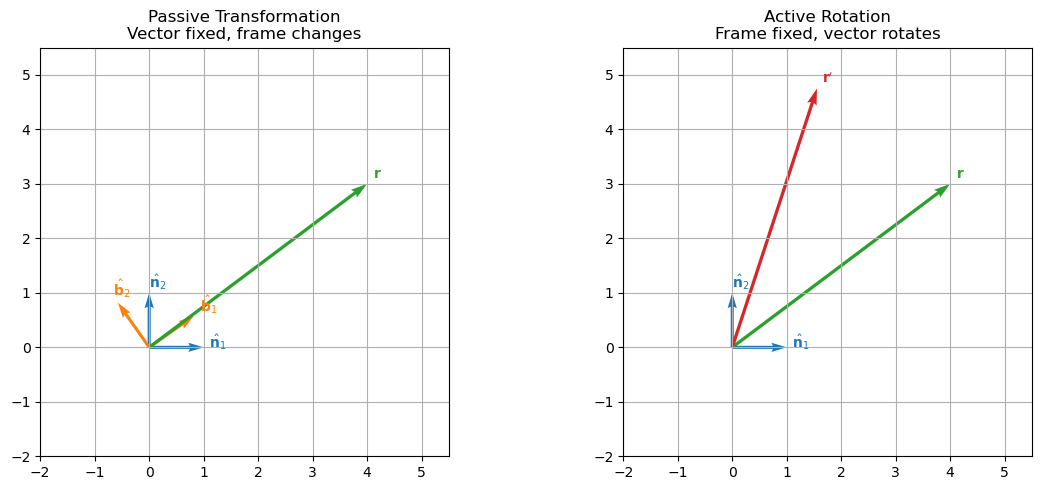

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Basis vectors of frame N
n1_N = np.array([1.0, 0.0])
n2_N = np.array([0.0, 1.0])

# Basis vectors of frame B expressed in frame N
b1_N = np.array([ c, s])
b2_N = np.array([-s, c])

# Passive transformation
ax = axes[0]

ax.quiver(
    0, 0, *n1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)
ax.quiver(
    0, 0, *n2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)

ax.quiver(
    0, 0, *b1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:orange"
)
ax.quiver(
    0, 0, *b2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:orange"
)

ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:green"
)

ax.text(1.1, 0.0, r"$\hat{\mathbf{n}}_1$", color="tab:blue")
ax.text(0.0, 1.1, r"$\hat{\mathbf{n}}_2$", color="tab:blue")
ax.text(*(1.15 * b1_N), r"$\hat{\mathbf{b}}_1$", color="tab:orange")
ax.text(*(1.15 * b2_N), r"$\hat{\mathbf{b}}_2$", color="tab:orange")
ax.text(
    r_N[0] + 0.1,
    r_N[1] + 0.1,
    r"$\mathbf{r}$",
    color="tab:green"
)

ax.set_title("Passive Transformation\nVector fixed, frame changes")
ax.set_xlim(-2, 5.5)
ax.set_ylim(-2, 5.5)
ax.set_aspect("equal")
ax.grid()


# Active rotation
ax = axes[1]

ax.quiver(
    0, 0, *n1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)
ax.quiver(
    0, 0, *n2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)

ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:green"
)

ax.quiver(
    0, 0, *r_rotated_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:red"
)

ax.text(1.1, 0.0, r"$\hat{\mathbf{n}}_1$", color="tab:blue")
ax.text(0.0, 1.1, r"$\hat{\mathbf{n}}_2$", color="tab:blue")

ax.text(
    r_N[0] + 0.1,
    r_N[1] + 0.1,
    r"$\mathbf{r}$",
    color="tab:green"
)

ax.text(
    r_rotated_N[0] + 0.1,
    r_rotated_N[1] + 0.1,
    r"$\mathbf{r}^{\prime}$",
    color="tab:red"
)

ax.set_title("Active Rotation\nFrame fixed, vector rotates")
ax.set_xlim(-2, 5.5)
ax.set_ylim(-2, 5.5)
ax.set_aspect("equal")
ax.grid()

plt.tight_layout()
plt.show()

**<ins>Intuitive Summary</ins>**

A vector is a physical geometric quantity. What changes from one reference frame to another is not the vector itself, but the **numbers used to describe it**.

The reference frame provides the origin and basis directions. Once a frame is chosen, the vector can be written through its components in that frame,

$$
[\mathbf r]_N.
$$

If we change the frame from $N$ to $B$ while keeping the physical vector fixed, we perform a **passive transformation**,

$$
[\mathbf r]_B = [C_{BN}][\mathbf r]_N.
$$

The vector has not moved. We have simply changed the coordinate system used to describe it.

An **active transformation** does the opposite. The reference frame stays fixed while the physical vector itself is rotated,

$$
[\mathbf r']_N = [R(\theta)][\mathbf r]_N.
$$

The easiest way to remember the difference is therefore

$$
\boxed{
\text{Passive: move the frame, keep the vector fixed}
}
$$

$$
\boxed{
\text{Active: keep the frame fixed, move the vector}
}
$$

For the same relative rotation, these operations act in opposite directions. Therefore,

$$
[C_{BN}] = [R(\theta)]^{-1} = [R(\theta)]^T.
$$

The transpose appears because rotation matrices are orthogonal, so reversing a rotation is equivalent to transposing its matrix.

Throughout these notes, transformations between reference frames will be treated as **passive transformations unless explicitly stated otherwise**.

With the ideas of vectors, frames, and coordinate representation established, the next question is:

> What happens when these vectors change with time?

This leads naturally to position, velocity, and acceleration.

## 1.1.2 - Position, Velocity and Acceleration

A reference frame allows us to describe **where** an object is. Kinematics extends this idea by asking how that position changes with time.

**<ins>Position</ins>**

Consider a particle $P$ whose position relative to the origin of reference frame $N$ is described by the position vector

$$
\mathbf r = x\hat{\mathbf n}_1 + y\hat{\mathbf n}_2 + z\hat{\mathbf n}_3.
$$

Its coordinate representation in frame $N$ is therefore

$$
[\mathbf r]_N =
\begin{bmatrix}
x\\
y\\
z
\end{bmatrix}.
$$

If the particle moves, the components $x$, $y$, and $z$ become functions of time,

$$
\mathbf r(t) = x(t)\hat{\mathbf n}_1 + y(t)\hat{\mathbf n}_2 + z(t)\hat{\mathbf n}_3.
$$

The position vector therefore answers the first kinematic question:

> Where is the particle relative to the chosen origin?

**<ins>Velocity</ins>**

Velocity describes how the position vector changes with time.

The velocity of $P$ observed from frame $N$ is defined as

$$
\mathbf v = {}^{N}\frac{d\mathbf r}{dt}.
$$

The superscript $N$ is important. It identifies the reference frame with respect to which the derivative is being taken.

If frame $N$ is non-rotating, its basis vectors do not change direction with time. Therefore,

$$
{}^{N}\frac{d\hat{\mathbf n}_i}{dt}=0,
$$

and the derivative reduces to

$$
\mathbf v = \dot{x}\hat{\mathbf n}_1 + \dot{y}\hat{\mathbf n}_2 + \dot{z}\hat{\mathbf n}_3.
$$

Hence,

$$
[\mathbf v]_N =
\begin{bmatrix}
\dot{x}\\
\dot{y}\\
\dot{z}
\end{bmatrix}.
$$

Velocity therefore describes both the **speed** and **direction of motion** of the particle. Geometrically, the velocity vector is tangent to the trajectory followed by the particle.

**<ins>Acceleration</ins>**

Acceleration describes how the velocity vector changes with time,

$$
\mathbf a = {}^{N}\frac{d\mathbf v}{dt} = {}^{N}\frac{d^2\mathbf r}{dt^2}.
$$

For a non-rotating frame $N$,

$$
\mathbf a = \ddot{x}\hat{\mathbf n}_1 + \ddot{y}\hat{\mathbf n}_2 + \ddot{z}\hat{\mathbf n}_3,
$$

with coordinate representation

$$
[\mathbf a]_N =
\begin{bmatrix}
\ddot{x}\\
\ddot{y}\\
\ddot{z}
\end{bmatrix}.
$$

Acceleration does not necessarily mean that the particle is speeding up or slowing down. Because velocity is a vector, acceleration may result from a change in

- the magnitude of the velocity,
- the direction of the velocity,
- or both.

A particle travelling at constant speed along a curved path therefore still experiences acceleration because the direction of its velocity is continuously changing.

The fundamental kinematic relationship can therefore be summarized as

$$
\boxed{
\mathbf r
\xrightarrow{\ d/dt\ }
\mathbf v
\xrightarrow{\ d/dt\ }
\mathbf a
}
$$

However, there is an important condition hidden inside these derivatives.

The expressions above were simple because the basis vectors of frame $N$ were assumed not to rotate. If the reference frame itself rotates, then

$$
{}^{N}\frac{d\hat{\mathbf b}_i}{dt} \neq 0,
$$

and differentiating only the scalar components of a vector is no longer sufficient.

This raises the next important question:

> How does the derivative of a vector change when the reference frame itself is moving or rotating?

In [4]:
# ---------------------------------------------------------------------------------------
# Position, velocity, and acceleration
#
# Consider a particle moving along a circular path:
#
#     r(t) = [R cos(wt), R sin(wt)]
#
# The velocity is the time derivative of position:
#
#     v(t) = dr/dt
#
# and the acceleration is the time derivative of velocity:
#
#     a(t) = dv/dt
#
# Even though the speed is constant, the velocity direction changes continuously,
# producing a non-zero acceleration directed toward the centre of the circle.
# ---------------------------------------------------------------------------------------

R = 4.0
w = 0.8
t = 1.0

# Position, velocity, and acceleration expressed in frame N
r_N = np.array([
    R * np.cos(w * t),
    R * np.sin(w * t)
])

v_N = np.array([
    -R * w * np.sin(w * t),
     R * w * np.cos(w * t)
])

a_N = np.array([
    -R * w**2 * np.cos(w * t),
    -R * w**2 * np.sin(w * t)
])

print(f"Time, t:           {t}")
print(f"Position, r_N:     {r_N}")
print(f"Velocity, v_N:     {v_N}")
print(f"Acceleration, a_N: {a_N}")

print(f"\nSpeed:            {np.linalg.norm(v_N):.3f}")
print(f"Acceleration:     {np.linalg.norm(a_N):.3f}")

Time, t:           1.0
Position, r_N:     [2.78682684 2.86942436]
Velocity, v_N:     [-2.29553949  2.22946147]
Acceleration, a_N: [-1.78356918 -1.83643159]

Speed:            3.200
Acceleration:     2.560


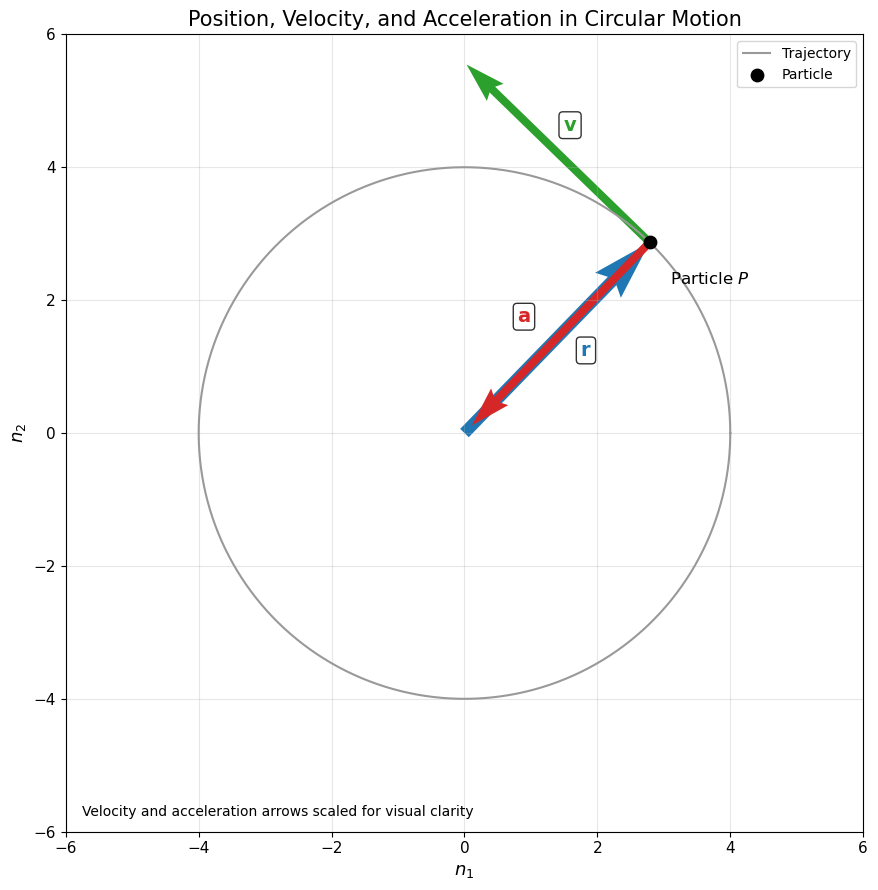

In [5]:
# ---------------------------------------------------------------------------------------
# Circular Motion: Position, Velocity, and Acceleration
#
# NumPy arrays are retained for vector algebra. Before passing 2-D coordinates to
# Matplotlib, as_xy() converts them to tuple[float, float]. This keeps the numerical
# representation natural while satisfying Matplotlib's static type expectations.
# ---------------------------------------------------------------------------------------

PlanarVector = NDArray[np.floating[Any]]


def as_xy(vector: PlanarVector) -> tuple[float, float]:
    """Convert a 2-D NumPy vector to Matplotlib (x, y) coordinates."""
    if vector.shape != (2,):
        raise ValueError(f"Expected shape (2,), got {vector.shape}")

    return float(vector[0]), float(vector[1])


# Circular trajectory
t_plot = np.linspace(0.0, 2.0 * np.pi / w, 400)

x = R * np.cos(w * t_plot)
y = R * np.sin(w * t_plot)


# Scale only the displayed arrows; the physical vectors remain unchanged.
v_scale = 1.2
a_scale = 1.5

v_plot_N = v_scale * v_N
a_plot_N = a_scale * a_N


# Convert NumPy vectors only at the plotting interface.
r_xy = as_xy(r_N)
v_plot_xy = as_xy(v_plot_N)
a_plot_xy = as_xy(a_plot_N)

r_label_xy = as_xy(0.55 * r_N)
v_label_xy = as_xy(r_N + 0.55 * v_plot_N)
a_label_xy = as_xy(r_N + 0.55 * a_plot_N)


fig, ax = plt.subplots(figsize=(9, 9))

ax.plot(
    x,
    y,
    color="0.6",
    linewidth=1.5,
    label="Trajectory"
)


# Position vector: origin -> particle
ax.quiver(
    0.0,
    0.0,
    *r_xy,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:blue",
    width=0.015
)


# Velocity vector: tangent to the trajectory at the particle
ax.quiver(
    *r_xy,
    *v_plot_xy,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:green",
    width=0.010
)


# Acceleration vector: directed toward the centre for circular motion
ax.quiver(
    *r_xy,
    *a_plot_xy,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:red",
    width=0.010
)


# Particle
ax.scatter(
    *r_xy,
    s=80,
    color="black",
    zorder=5,
    label="Particle"
)


# Reuse the same annotation style for all vector labels.
annotation_box: dict[str, Any] = {
    "boxstyle": "round,pad=0.2",
    "facecolor": "white",
    "alpha": 0.8,
}


ax.annotate(
    r"$\mathbf{r}$",
    xy=r_label_xy,
    xytext=(10, -20),
    textcoords="offset points",
    fontsize=14,
    color="tab:blue",
    bbox=annotation_box
)

ax.annotate(
    r"$\mathbf{v}$",
    xy=v_label_xy,
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=14,
    color="tab:green",
    bbox=annotation_box
)

ax.annotate(
    r"$\mathbf{a}$",
    xy=a_label_xy,
    xytext=(-25, 15),
    textcoords="offset points",
    fontsize=14,
    color="tab:red",
    bbox=annotation_box
)

ax.annotate(
    "Particle $P$",
    xy=r_xy,
    xytext=(15, -30),
    textcoords="offset points",
    fontsize=12
)


ax.set_title(
    "Position, Velocity, and Acceleration in Circular Motion",
    fontsize=15
)

ax.set_xlabel(r"$n_1$", fontsize=13)
ax.set_ylabel(r"$n_2$", fontsize=13)

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal", adjustable="box")

ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)
ax.legend()


ax.text(
    0.02,
    0.02,
    "Velocity and acceleration arrows scaled for visual clarity",
    transform=ax.transAxes,
    fontsize=10
)

fig.tight_layout()
plt.show()

## 1.1.3 - Newton's Laws and Inertial Frames

In the previous section, acceleration was introduced as the time rate of change of velocity,

$$
\mathbf a = {}^{N}\frac{d\mathbf v}{dt} = {}^{N}\frac{d^2\mathbf r}{dt^2}.
$$

Kinematics describes how a particle moves. **Dynamics** introduces the physical causes of that motion.

The connection between the two is provided by Newton's laws.

**<ins>Newton's First Law</ins>**

Newton's first law states that a particle remains at rest or continues moving with constant velocity unless acted upon by a net external force.

Therefore, if

$$
\sum \mathbf F = \mathbf 0,
$$

then

$$
\mathbf v = \text{constant}.
$$

This statement also gives us a practical definition of an **inertial reference frame**: a frame in which a force-free particle moves with constant velocity.

An inertial frame therefore has no translational acceleration and does not rotate relative to inertial space. It may, however, translate at constant velocity.

**<ins>Newton's Second Law</ins>**

Newton's second law relates the net external force acting on a particle to its acceleration.

For a particle of constant mass,

$$
\sum \mathbf F = m\mathbf a.
$$

Using the kinematic definition of acceleration,

$$
\boxed{
\sum \mathbf F = m\,{}^{N}\frac{d^2\mathbf r}{dt^2}
}
$$

where $N$ must be an inertial reference frame.

This condition is important. The familiar expression

$$
\sum \mathbf F = m\ddot{\mathbf r}
$$

does not mean that $\mathbf r$ may be differentiated with respect to any arbitrary observer. The derivatives must represent the acceleration measured relative to an inertial frame.

If the observing frame itself accelerates or rotates, the measured acceleration contains additional terms associated with the motion of the frame.

**<ins>Newton's Third Law</ins>**

Newton's third law states that forces between two interacting bodies occur in equal and opposite pairs.

If body $A$ exerts a force on body $B$,

$$
\mathbf F_{A\rightarrow B},
$$

then body $B$ exerts

$$
\mathbf F_{B\rightarrow A} = -\mathbf F_{A\rightarrow B}.
$$

These forces have equal magnitude and opposite direction, but act on different bodies.

This becomes particularly useful when considering gravitational interactions between spacecraft and celestial bodies.

**<ins>Inertial Frames in Orbital Mechanics</ins>**

For spacecraft motion about Earth, an Earth-Centered Inertial (ECI) frame is commonly used. Its origin is placed at the centre of the Earth, while its coordinate axes are treated as non-rotating.

Strictly speaking, the Earth's centre is not perfectly inertial because it accelerates as Earth orbits the Sun. However, for many Earth-orbit problems this acceleration can be neglected over the time scale of interest, allowing the Earth-centred frame to be treated as approximately inertial.

This is an example of an important modelling principle:

> A reference frame does not need to be perfectly inertial in an absolute sense. It needs to be sufficiently inertial for the dynamics being modelled.

**<ins>Why This Matters for Relative Motion</ins>**

For a single spacecraft, Newton's second law can be applied directly to its position relative to an inertial origin,

$$
m\ddot{\mathbf r} = \sum \mathbf F.
$$

Relative spacecraft motion is more subtle.

Suppose two spacecraft have inertial position vectors

$$
\mathbf r_1
\qquad\text{and}\qquad
\mathbf r_2.
$$

Their relative position may be defined as

$$
\boldsymbol\rho = \mathbf r_2-\mathbf r_1.
$$

Although $\boldsymbol\rho$ describes the position of one spacecraft relative to another, it is not automatically a position vector measured from an inertial origin.

If the relative motion is expressed using a rotating frame attached to one spacecraft, then simply writing

$$
m\ddot{\boldsymbol\rho} = \mathbf F
$$

would generally be incorrect.

We first need to understand how derivatives of vectors observed in one reference frame are related to derivatives observed in another.

This leads to the **transport theorem**, which provides the mathematical connection between vector derivatives taken in different reference frames.

## 1.1.4 - Rotating Frames and Transport Theorem

So far, vector differentiation has been straightforward because the observing frame has been assumed to be non-rotating.

For a vector expressed in frame $B$,

$$
\mathbf r = r_1\hat{\mathbf b}_1 + r_2\hat{\mathbf b}_2 + r_3\hat{\mathbf b}_3,
$$

the vector may change for two different reasons:

1. its scalar components $r_1$, $r_2$, and $r_3$ may change with time, or
2. the basis vectors $\hat{\mathbf b}_1$, $\hat{\mathbf b}_2$, and $\hat{\mathbf b}_3$ may themselves rotate.

This distinction is what makes vector differentiation in rotating reference frames different from ordinary component-wise differentiation.

**<ins>Angular Velocity of a Reference Frame</ins>**

Let frame $B$ rotate relative to frame $N$ with angular velocity

$$
\boldsymbol\omega_{B/N}.
$$

This notation describes the angular velocity of frame $B$ relative to frame $N$.

If a basis vector $\hat{\mathbf b}_i$ is fixed in frame $B$, then an observer attached to $B$ sees no change in that basis vector,

$$
{}^{B}\frac{d\hat{\mathbf b}_i}{dt} = 0.
$$

However, an observer in frame $N$ sees the basis vector rotating. Its derivative is therefore

$$
{}^{N}\frac{d\hat{\mathbf b}_i}{dt} = \boldsymbol\omega_{B/N} \times \hat{\mathbf b}_i.
$$

The cross product appears because the instantaneous change of a rotating vector is perpendicular to both the vector itself and the axis of rotation.

**<ins>Deriving the Transport Theorem</ins>**

Consider again

$$
\mathbf r = r_1\hat{\mathbf b}_1 + r_2\hat{\mathbf b}_2 + r_3\hat{\mathbf b}_3.
$$

Differentiating with respect to frame $N$ gives

$$
{}^{N}\frac{d\mathbf r}{dt} = \sum_{i=1}^{3} \left( \dot r_i\hat{\mathbf b}_i + r_i\,{}^{N}\frac{d\hat{\mathbf b}_i}{dt} \right).
$$

The first term represents the change in the vector components as observed in frame $B$,

$$
{}^{B}\frac{d\mathbf r}{dt} = \sum_{i=1}^{3} \dot r_i\hat{\mathbf b}_i.
$$

Using

$$
{}^{N}\frac{d\hat{\mathbf b}_i}{dt} = \boldsymbol\omega_{B/N} \times \hat{\mathbf b}_i,
$$

the second term becomes

$$
\boldsymbol\omega_{B/N} \times \mathbf r.
$$

Therefore,

$$
\boxed{
{}^{N}\frac{d\mathbf r}{dt} = {}^{B}\frac{d\mathbf r}{dt} + \boldsymbol\omega_{B/N} \times \mathbf r
}
$$

This relationship is known as the **transport theorem**.

It tells us that the rate of change of a vector observed from frame $N$ consists of two contributions:

$$
\boxed{
\text{change observed in }B + \text{change caused by rotation of }B
}
$$

A useful limiting case occurs when $\mathbf r$ is completely fixed in frame $B$,

$$
{}^{B}\frac{d\mathbf r}{dt}=0.
$$

An observer in frame $N$ still sees the vector changing because frame $B$ itself is rotating,

$$
{}^{N}\frac{d\mathbf r}{dt} = \boldsymbol\omega_{B/N} \times \mathbf r.
$$

This is the same idea encountered earlier with passive transformations, except the reference frame is now changing continuously with time.

**<ins>Acceleration in a Rotating Frame</ins>**

The transport theorem can be applied a second time to obtain acceleration.

Starting with

$$
{}^{N}\frac{d\mathbf r}{dt} = {}^{B}\frac{d\mathbf r}{dt} + \boldsymbol\omega_{B/N} \times \mathbf r,
$$

and differentiating once more with respect to frame $N$ gives

$$
\boxed{
{}^{N}\frac{d^2\mathbf r}{dt^2} = 

{}^{B}\frac{d^2\mathbf r}{dt^2}
+
2\boldsymbol\omega_{B/N}
\times
{}^{B}\frac{d\mathbf r}{dt}
+
\dot{\boldsymbol\omega}_{B/N}
\times
\mathbf r
+
\boldsymbol\omega_{B/N}
\times
\left(
\boldsymbol\omega_{B/N}
\times
\mathbf r
\right)
}
$$

Each additional term has a physical interpretation:

- ${}^{B}d^2\mathbf r/dt^2$ is the acceleration measured within the rotating frame.
- $2\boldsymbol\omega_{B/N}\times{}^{B}d\mathbf r/dt$ is the **Coriolis term**.
- $\dot{\boldsymbol\omega}_{B/N}\times\mathbf r$ is the **Euler term**, produced when the frame's angular velocity changes.
- $\boldsymbol\omega_{B/N}\times(\boldsymbol\omega_{B/N}\times\mathbf r)$ is the **centrifugal term** associated with the rotation of the frame.

These are not additional physical forces acting on the particle. They appear because the motion is being described from a rotating reference frame.

**<ins>Moving Origins</ins>**

In many relative-motion problems, the rotating frame also has a moving origin.

Let $O$ be the origin of frame $B$, and let $\boldsymbol\rho$ describe the position of particle $P$ relative to $O$. The inertial position of $P$ can then be written as

$$
\mathbf r_P = \mathbf r_O + \boldsymbol\rho.
$$

Its inertial velocity becomes

$$
{}^{N}\frac{d\mathbf r_P}{dt} =
{}^{N}\frac{d\mathbf r_O}{dt}
+
{}^{B}\frac{d\boldsymbol\rho}{dt}
+
\boldsymbol\omega_{B/N}
\times
\boldsymbol\rho.
$$

Similarly, its inertial acceleration is

$$
{}^{N}\frac{d^2\mathbf r_P}{dt^2} =
{}^{N}\frac{d^2\mathbf r_O}{dt^2}
+
{}^{B}\frac{d^2\boldsymbol\rho}{dt^2}
+
2\boldsymbol\omega_{B/N}
\times
{}^{B}\frac{d\boldsymbol\rho}{dt}
+
\dot{\boldsymbol\omega}_{B/N}
\times
\boldsymbol\rho
+
\boldsymbol\omega_{B/N}
\times
\left(
\boldsymbol\omega_{B/N}
\times
\boldsymbol\rho
\right).
$$

This expression will become particularly important in spacecraft relative motion, where a rotating reference frame is often attached to a reference spacecraft whose origin is itself moving along an orbit.

The key idea is therefore

$$
\boxed{
\text{Different observers can measure different vector derivatives,
even when they are describing the same physical vector.}
}
$$

The transport theorem provides the mathematical relationship between those observations.

## 1.1.5 - Applied Example: Multi-Frame Kinematics

The following example brings together the concepts developed throughout this section: position-vector composition, rotating reference frames, relative angular velocity, and frame-dependent vector differentiation.

A simplified planar system consisting of the Sun, Earth, Moon, and an additional object orbiting the Sun is considered. The same physical motion will later be examined from several reference frames to illustrate how position and its derivatives depend on the observer.

<div align="center">
    <img src="Images/Quiz2_Qn2.png" width="650">
</div>

<p align="center">
    <em>Multi-frame kinematics problem used throughout this example.</em>
</p>

**<ins>Reference Frames and Motion</ins>**

Four reference frames are defined:

$$
\mathcal N =
\left\{
\hat{\mathbf n}_1,
\hat{\mathbf n}_2,
\hat{\mathbf n}_3
\right\},
$$

a Sun-centred inertial frame,

$$
\mathcal E =
\left\{
\hat{\mathbf e}_r,
\hat{\mathbf e}_\phi,
\hat{\mathbf e}_3
\right\},
$$

an Earth-centred frame rotating with the Earth about the Sun,

$$
\mathcal M =
\left\{
\hat{\mathbf m}_r,
\hat{\mathbf m}_\theta,
\hat{\mathbf m}_3
\right\},
$$

a Moon-centred frame rotating with the Moon about the Earth, and

$$
\mathcal U =
\left\{
\hat{\mathbf u}_r,
\hat{\mathbf u}_\gamma,
\hat{\mathbf u}_3
\right\},
$$

a UFO-centred frame rotating with the UFO about the Sun.

The corresponding angular velocities are

$$
\boldsymbol{\omega}_{E/N} = \dot{\phi}\,\hat{\mathbf n}_3,
$$

$$
\boldsymbol{\omega}_{M/E} = \dot{\theta}\,\hat{\mathbf n}_3,
$$

and

$$
\boldsymbol{\omega}_{U/N} = \dot{\gamma}\,\hat{\mathbf n}_3
$$

Because the motion is planar,

$$
\hat{\mathbf n}_3 =
\hat{\mathbf e}_3 =
\hat{\mathbf m}_3 =
\hat{\mathbf u}_3
$$

The principal position vectors are

$$
\mathbf r_{E/S}=R\hat{\mathbf e}_r,
\qquad
\mathbf r_{M/E}=r\hat{\mathbf m}_r,
\qquad
\mathbf r_{U/S}=R_2\hat{\mathbf u}_r
$$

The radii $R$, $r$, and $R_2$, together with the angular rates $\dot{\phi}$, $\dot{\theta}$, and $\dot{\gamma}$, are assumed constant for this example.

### 1.1.5.1 - Symbolic Multi_frame Kinematics

In [6]:
# ---------------------------------------------------------------------------------------
# Symbolic Model Setup: Parameters, Reference Frames, and Display Utilities
#
# This cell establishes the symbolic quantities and four reference frames used
# throughout the multi-frame kinematics example.
#
#     N : Sun-centred inertial frame
#     E : Earth orbital frame
#     M : Moon orbital frame
#     U : UFO orbital frame
#
# R, r, R2 and the angular rates are constant for this problem.
#
# The display helpers are defined here because later cells repeatedly inspect symbolic
# vectors and frame definitions; keeping them with the model setup avoids redefining
# presentation logic during the derivation.
# ---------------------------------------------------------------------------------------

t = dynamicsymbols._t

# Constant radii
R, r, R2 = sp.symbols(
    "R r R_2",
    positive=True,
    real=True
)

# Constant angular rates
phi_dot, theta_dot, gamma_dot = sp.symbols(
    r"\dot{\phi} \dot{\theta} \dot{\gamma}",
    real=True
)


# Reference frames
N = ReferenceFrame(
    "N",
    indices=("1", "2", "3"),
    latexs=(
        r"\hat{\mathbf n}_1",
        r"\hat{\mathbf n}_2",
        r"\hat{\mathbf n}_3"
    )
)

E = ReferenceFrame(
    "E",
    indices=("r", "phi", "3"),
    latexs=(
        r"\hat{\mathbf e}_r",
        r"\hat{\mathbf e}_\phi",
        r"\hat{\mathbf e}_3"
    )
)

M = ReferenceFrame(
    "M",
    indices=("r", "theta", "3"),
    latexs=(
        r"\hat{\mathbf m}_r",
        r"\hat{\mathbf m}_\theta",
        r"\hat{\mathbf m}_3"
    )
)

U = ReferenceFrame(
    "U",
    indices=("r", "gamma", "3"),
    latexs=(
        r"\hat{\mathbf u}_r",
        r"\hat{\mathbf u}_\gamma",
        r"\hat{\mathbf u}_3"
    )
)


def show_expr(lhs, rhs):
    """Display a symbolic expression in rendered mathematical notation."""
    display(Math(rf"{lhs} = {sp.latex(rhs)}"))

def show_frame(symbol: str, frame: ReferenceFrame) -> None:
    """Display the basis vectors that define a reference frame."""
    basis = (
        sp.latex(frame.x),
        sp.latex(frame.y),
        sp.latex(frame.z),
    )

    display(
        Math(
            rf"\mathcal{{{symbol}}}"
            rf" = \left\{{{basis[0]},\,{basis[1]},\,{basis[2]}\right\}}"
        )
    )


# Inspect the reference frames defined above.
show_frame("N", N)
show_frame("E", E)
show_frame("M", M)
show_frame("U", U)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
# ---------------------------------------------------------------------------------------
# Frame Kinematics
#
# orient_axis(parent, axis, angle) defines the orientation of a moving frame relative
# to a parent frame.
#
# For this planar problem, each frame rotates about the common out-of-plane z-axis.
# Because the angular rates are constant, the corresponding rotation angles are
#
#     phi(t)   = phi_dot   * t
#     theta(t) = theta_dot * t
#     gamma(t) = gamma_dot * t
#
# Once these frame relationships are defined, SymPy can derive angular velocities
# between connected frames and use them in frame-dependent vector derivatives.
# ---------------------------------------------------------------------------------------

E.orient_axis(
    N,            # parent/reference frame
    N.z,          # axis about which E rotates
    phi_dot * t   # rotation angle
)

M.orient_axis(
    E,
    E.z,
    theta_dot * t
)

U.orient_axis(
    N,
    N.z,
    gamma_dot * t
)


# Inspect the angular velocities implied by the frame definitions
omega_E_N = cast(Vector, E.ang_vel_in(N).express(N)).simplify()
omega_M_E = cast(Vector, M.ang_vel_in(E).express(E)).simplify()
omega_M_N = cast(Vector, M.ang_vel_in(N).express(N)).simplify()
omega_U_N = cast(Vector, U.ang_vel_in(N).express(N)).simplify()

# Show expressions:
show_expr(
    r"\boldsymbol{\omega}_{E/N}",
    omega_E_N
)

show_expr(
    r"\boldsymbol{\omega}_{M/E}",
    omega_M_E
)

show_expr(
    r"\boldsymbol{\omega}_{M/N}",
    omega_M_N
)

show_expr(
    r"\boldsymbol{\omega}_{U/N}",
    omega_U_N
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
# ---------------------------------------------------------------------------------------
# Position-Vector Geometry
#
# Define the three primitive position vectors directly from the diagram, then build
# the required relative-position vectors by following vector paths between bodies.
# ---------------------------------------------------------------------------------------

r_E_S = R * E.x     # E.x = e_r
r_M_E = r * M.x     # M.x = m_r
r_U_S = R2 * U.x    # U.x = u_r    


# Moon relative to Sun: S -> E -> M
r_M_S = (r_E_S + r_M_E).simplify()


# Moon relative to UFO: U -> S -> E -> M
r_M_U = (r_M_E + r_E_S -r_U_S).simplify()


show_expr(
    r"\mathbf r_{E/S}",
    r_E_S
)

show_expr(
    r"\mathbf r_{M/E}",
    r_M_E
)

show_expr(
    r"\mathbf r_{U/S}",
    r_U_S
)

show_expr(
    r"\mathbf r_{M/S}",
    r_M_S
)

show_expr(
    r"\mathbf r_{M/U}",
    r_M_U
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
# ---------------------------------------------------------------------------------------
# Question 2: Inertial Acceleration of the Moon Relative to the Sun
#
# The known position vector is
#
#     r_M/S = r_E/S + r_M/E
#
# Naming convention:
#
#     v_M_S_N  -> velocity of M relative to S, differentiated with respect to N
#     a_M_S_N  -> acceleration of M relative to S, differentiated with respect to N
#
# In SymPy:
#
#     vector.dt(N)     -> take the time derivative as observed from frame N
#     .simplify()      -> algebraically simplify the resulting symbolic vector
#
# Since N is inertial, differentiating r_M/S twice in N gives the requested
# inertial acceleration.
# ---------------------------------------------------------------------------------------

v_M_S_N = r_M_S.dt(N).simplify()


a_M_S_N = v_M_S_N.dt(N).simplify()


show_expr(
    r"{}^N\frac{d\mathbf r_{M/S}}{dt}",
    v_M_S_N
)

show_expr(
    r"{}^N\frac{d^2\mathbf r_{M/S}}{dt^2}",
    a_M_S_N
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [10]:
# ---------------------------------------------------------------------------------------
# Question 3
#
# Find the position of the Moon relative to the UFO.
#
# Follow a vector path from U to M:
#
#     U -> S -> E -> M
# ---------------------------------------------------------------------------------------

r_M_U = (r_M_E + r_E_S - r_U_S).simplify()


show_expr(
    r"\mathbf r_{M/U}",
    r_M_U
)

<IPython.core.display.Math object>

In [11]:
# ---------------------------------------------------------------------------------------
# Question 4: Angular Velocity of M Relative to U
#
# Use the frame chain
#
#     M -> E -> U
#
# First determine the angular velocity of E relative to U, then combine it with
# the angular velocity of M relative to E.
#
# In SymPy:
#
#     frame.ang_vel_in(U)  -> angular velocity of the frame relative to U (Method is from sympy ReferenceFrame)
#     .express(U)          -> express that vector using the U-frame basis
#     .simplify()          -> algebraically simplify the symbolic result
#
# cast(Vector, ...) is only a type-checking hint for Pylance. It tells the type
# checker to treat the SymPy result as a Vector; it does not modify the vector
# or affect the mathematical calculation.
# ---------------------------------------------------------------------------------------

# Omega_E/U expressed in the U-Frame
omega_E_U_in_U = cast(Vector, E.ang_vel_in(U).express(U)).simplify()

# Omega_M/E expressed in the U-Frame
omega_M_E_in_U = cast(Vector, M.ang_vel_in(E).express(U)).simplify()

# Omega_M/U expressed in the U-Frame
omega_M_U_in_U = cast(Vector, M.ang_vel_in(U).express(U)).simplify()



show_expr(
    r"\boldsymbol{\omega}_{E/U}",
    omega_E_U_in_U
)

show_expr(
    r"\boldsymbol{\omega}_{M/E}",
    omega_M_E_in_U
)

show_expr(
    r"\boldsymbol{\omega}_{M/U}",
    omega_M_U_in_U
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [12]:
# ---------------------------------------------------------------------------------------
# Question 5
#
# Find the acceleration of the Moon as measured by an observer fixed in U.
#
# This is NOT the inertial second derivative of r_M/U.
#
# The derivatives must explicitly be taken with respect to frame U.
# ---------------------------------------------------------------------------------------

v_M_U_U = r_M_U.dt(U).simplify()

a_M_U_U = v_M_U_U.dt(U)#.simplify()


show_expr(
    r"{}^U\frac{d\mathbf r_{M/U}}{dt}",
    v_M_U_U
)

show_expr(
    r"{}^U\frac{d^2\mathbf r_{M/U}}{dt^2}",
    a_M_U_U
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:
# ---------------------------------------------------------------------------------------
# Frame-dependence check
#
# Take the SAME geometric relative-position vector r_M/U and differentiate it
# using two different observers.
#
# The vector is the same. The measured derivatives are not.
# ---------------------------------------------------------------------------------------

a_M_U_N = r_M_U.dt(N).dt(N).simplify()


a_M_U_U_check = r_M_U.dt(U).dt(U)#.simplify()


show_expr(
    r"{}^N\frac{d^2\mathbf r_{M/U}}{dt^2}",
    a_M_U_N
)

show_expr(
    r"{}^U\frac{d^2\mathbf r_{M/U}}{dt^2}",
    a_M_U_U_check
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 1.1.5.2 - Visual Interpretation across Reference Frames

In [14]:
# ---------------------------------------------------------------------------------------
# Numerical Motion Model
#
# Define the radii, constant angular rates, initial angles, and simulation time grid.
# The values are illustrative rather than physically scaled so that the relative
# trajectories remain easy to inspect.
# ---------------------------------------------------------------------------------------

R = 6.0
r = 1.5
R2 = 9.0

phi_dot = 0.20
theta_dot = 0.65
gamma_dot = 0.12

phi_0 = np.deg2rad(0.0)
theta_0 = np.deg2rad(0.0)
gamma_0 = np.deg2rad(0.0)

t_end = 90.0
n_frames = 241

time = np.linspace(0.0, t_end, n_frames)


# Constant angular rates give angles that vary linearly with time.
phi = phi_0 + phi_dot * time
theta = theta_0 + theta_dot * time
gamma = gamma_0 + gamma_dot * time


# Inspect the numerical model before constructing any trajectories.
print(f"Time span       : {time[0]:.1f} -> {time[-1]:.1f}")
print(f"Samples         : {len(time)}")
print(f"Earth rate      : {phi_dot:.2f}")
print(f"Moon/Earth rate : {theta_dot:.2f}")
print(f"UFO rate        : {gamma_dot:.2f}")

Time span       : 0.0 -> 90.0
Samples         : 241
Earth rate      : 0.20
Moon/Earth rate : 0.65
UFO rate        : 0.12


In [15]:
# ---------------------------------------------------------------------------------------
# Inertial Trajectories
#
# Construct every body position in the Sun-centred inertial frame N.
# These are the physical trajectories from which all observer-frame views are derived.
# ---------------------------------------------------------------------------------------

FloatArray = NDArray[np.float64]

# Sun is fixed at the origin of N.
r_S_N: FloatArray = np.zeros(
    (n_frames, 2),
    dtype=np.float64,
)

# Earth relative to the Sun.
r_E_N: FloatArray = np.asarray(
    np.column_stack([
        R * np.cos(phi),
        R * np.sin(phi),
    ]),
    dtype=np.float64,
)

# Moon relative to Earth.
r_M_E_N: FloatArray = np.asarray(
    np.column_stack([
        r * np.cos(phi + theta),
        r * np.sin(phi + theta),
    ]),
    dtype=np.float64,
)

# Moon relative to the Sun: S -> E -> M.
r_M_N: FloatArray = np.asarray(
    r_E_N + r_M_E_N,
    dtype=np.float64,
)

# UFO relative to the Sun.
r_U_N: FloatArray = np.asarray(
    np.column_stack([
        R2 * np.cos(gamma),
        R2 * np.sin(gamma),
    ]),
    dtype=np.float64,
)

bodies_N = {
    "Sun": r_S_N,
    "Earth": r_E_N,
    "Moon": r_M_N,
    "UFO": r_U_N,
}


# Verify the geometric assumptions used to construct the trajectories.
earth_radius_error = np.max(
    np.abs(np.linalg.norm(r_E_N, axis=1) - R)
)

moon_radius_error = np.max(
    np.abs(np.linalg.norm(r_M_E_N, axis=1) - r)
)

ufo_radius_error = np.max(
    np.abs(np.linalg.norm(r_U_N, axis=1) - R2)
)

print(f"Earth orbit radius error : {earth_radius_error:.2e}")
print(f"Moon orbit radius error  : {moon_radius_error:.2e}")
print(f"UFO orbit radius error   : {ufo_radius_error:.2e}")

Earth orbit radius error : 8.88e-16
Moon orbit radius error  : 2.22e-16
UFO orbit radius error   : 1.78e-15


In [16]:
# ---------------------------------------------------------------------------------------
# Observer Frames
#
# Each observer frame is defined by:
#
#     origin_N    -> trajectory of the frame origin expressed in N
#     angle       -> orientation of the frame relative to N
#     name        -> descriptive label used by the visualizer
#     axis_labels -> basis directions used when plotting in that frame
#
# A dataclass keeps these related properties together and gives the frame definition
# an explicit structure, rather than maintaining several parallel dictionaries.
# ---------------------------------------------------------------------------------------

@dataclass
class ObserverFrame:
    """Store the numerical and display properties of an observer frame."""

    origin_N: NDArray[np.float64]
    angle: NDArray[np.float64]
    name: str
    axis_labels: tuple[str, str]


# Plotly-facing basis labels use LaTeX, with MathJax supplied when the final
# visualization is rendered.
observer_frames = {
    "N": ObserverFrame(
        origin_N=r_S_N,
        angle=np.zeros(n_frames),
        name="Sun-centred Inertial Frame N",
        axis_labels=(
            r"$\hat{\mathbf{n}}_1$",
            r"$\hat{\mathbf{n}}_2$",
        ),
    ),

    "E": ObserverFrame(
        origin_N=r_E_N,
        angle=phi,
        name="Earth Frame E",
        axis_labels=(
            r"$\hat{\mathbf{e}}_r$",
            r"$\hat{\mathbf{e}}_\phi$",
        ),
    ),

    "M": ObserverFrame(
        origin_N=r_M_N,
        angle=phi + theta,
        name="Moon Frame M",
        axis_labels=(
            r"$\hat{\mathbf{m}}_r$",
            r"$\hat{\mathbf{m}}_\theta$",
        ),
    ),

    "U": ObserverFrame(
        origin_N=r_U_N,
        angle=gamma,
        name="UFO Frame U",
        axis_labels=(
            r"$\hat{\mathbf{u}}_r$",
            r"$\hat{\mathbf{u}}_\gamma$",
        ),
    ),
}


# Inspect the complete definition of each observer.
for symbol, frame in observer_frames.items():
    print(
        f"{symbol}: {frame.name}, "
        f"initial angle = {np.rad2deg(frame.angle[0]):.1f} deg"
    )

N: Sun-centred Inertial Frame N, initial angle = 0.0 deg
E: Earth Frame E, initial angle = 0.0 deg
M: Moon Frame M, initial angle = 0.0 deg
U: UFO Frame U, initial angle = 0.0 deg


In [17]:
# ---------------------------------------------------------------------------------------
# Passive Frame Transformation
#
# Let F denote a generic observer frame. In this example:
#
#     F = N, E, M, or U
#
# For a body P observed from frame F:
#
#     [r_P/F]_N = [r_P/N]_N - [r_F/N]_N
#
#     [r_P/F]_F = C_FN [r_P/F]_N
#
# The first operation changes the origin from N to F while retaining the N basis.
# The second operation passively rotates the relative-position coordinates from
# the N basis into the basis of the selected observer frame F.
#
# The transformation is vectorized here: instead of looping through each time step,
# all time-dependent DCMs are constructed together and applied to the complete
# trajectory in one NumPy operation.
# ---------------------------------------------------------------------------------------

def transform_trajectory(
    position_N: FloatArray,
    observer_symbol: str,
) -> FloatArray:
    """Express an inertial trajectory in the selected observer frame."""

    frame = observer_frames[observer_symbol]

    # ---------------------------------------------------------------------------
    # 1. Change the origin from N to F.
    #
    # position_N      shape: (n_frames, 2)
    # frame.origin_N  shape: (n_frames, 2)
    #
    # Each row contains the planar position vector at one simulation time.
    # ---------------------------------------------------------------------------

    relative_position_N = position_N - frame.origin_N


    # ---------------------------------------------------------------------------
    # 2. Construct the passive DCM C_FN at every simulation time.
    #
    # For one time step:
    #
    #          [ cos(alpha)   sin(alpha)]
    # C_FN  =  [-sin(alpha)   cos(alpha)]
    #
    # frame.angle contains alpha(t) for every simulation time, so c and s are
    # one-dimensional arrays with shape:
    #
    #     (n_frames,)
    # ---------------------------------------------------------------------------

    c = np.cos(frame.angle)
    s = np.sin(frame.angle)


    # Build all C_FN matrices simultaneously.
    #
    # The resulting array has shape:
    #
    #     (n_frames, 2, 2)
    #
    # so that C_FN[k] is the DCM applicable at simulation time t[k].
    C_FN = np.stack(
        [
            np.column_stack([c, s]),
            np.column_stack([-s, c]),
        ],
        axis=1,
    )


    # ---------------------------------------------------------------------------
    # 3. Apply each DCM to the corresponding relative-position vector.
    #
    # relative_position_N initially has shape:
    #
    #     (n_frames, 2)
    #
    # Matrix multiplication requires each position to behave as a 2x1 column
    # vector, so a final singleton dimension is temporarily added:
    #
    #     (n_frames, 2) -> (n_frames, 2, 1)
    #
    # NumPy then performs the batch multiplication:
    #
    #     C_FN[k] @ relative_position_N[k]
    #
    # for every k simultaneously.
    # ---------------------------------------------------------------------------

    relative_position_N_column = relative_position_N[..., np.newaxis]

    relative_position_F_column = (
        C_FN @ relative_position_N_column
    )


    # Remove the temporary final dimension:
    #
    #     (n_frames, 2, 1) -> (n_frames, 2)
    #
    # The result is the complete trajectory expressed in frame F.
    relative_position_F = relative_position_F_column[..., 0]

    return relative_position_F


# Every observer must remain at the origin of its own frame.
for observer_symbol, frame in observer_frames.items():

    origin_in_own_frame = transform_trajectory(
        frame.origin_N,
        observer_symbol,
    )

    # Measure the largest deviation from the expected origin (0, 0).
    origin_residual = np.linalg.norm(
        origin_in_own_frame,
        axis=1,
    )

    maximum_origin_residual = np.max(
        origin_residual
    )

    print(
        f"{observer_symbol} origin residual: "
        f"{maximum_origin_residual:.2e}"
    )


# In the rotating UFO frame, the Sun should remain fixed at (-R2, 0).
sun_in_U = transform_trajectory(
    r_S_N,
    "U",
)

expected_sun_position_U = np.array([
    -R2,
    0.0,
])

sun_position_error = (
    sun_in_U - expected_sun_position_U
)

maximum_sun_position_error = np.max(
    np.linalg.norm(
        sun_position_error,
        axis=1,
    )
)


print(
    "\nSun in U at t = 0:",
    np.round(sun_in_U[0], 6),
)

print(
    "Expected Sun position:",
    expected_sun_position_U,
)

print(
    "Maximum Sun position error:",
    f"{maximum_sun_position_error:.2e}",
)

N origin residual: 0.00e+00
E origin residual: 0.00e+00
M origin residual: 0.00e+00
U origin residual: 0.00e+00

Sun in U at t = 0: [-9.  0.]
Expected Sun position: [-9.  0.]
Maximum Sun position error: 1.99e-15


In [18]:
# ---------------------------------------------------------------------------------------
# Relative Trajectory Database
#
# Apply the same passive frame transformation to every body for every observer frame.
#
# Each entry therefore stores:
#
#     trajectories[F][P] = [r_P/F]_F
#
# where F is the selected observer frame and P is the body being observed.
#
# The physical motion does not change between observers; only the origin and coordinate
# basis used to describe that motion change.
# ---------------------------------------------------------------------------------------

trajectories = {
    observer_symbol: {
        body_name: transform_trajectory(
            position_N,
            observer_symbol,
        )
        for body_name, position_N in bodies_N.items()
    }
    for observer_symbol in observer_frames
}


# Inspect the Moon's initial position as described by each observer frame.
for observer_symbol, frame in observer_frames.items():

    moon_position = trajectories[observer_symbol]["Moon"][0]

    print(
        f"Moon seen from {observer_symbol} "
        f"({frame.name}): "
        f"({moon_position[0]:.3f}, {moon_position[1]:.3f})"
    )

Moon seen from N (Sun-centred Inertial Frame N): (7.500, 0.000)
Moon seen from E (Earth Frame E): (1.500, 0.000)
Moon seen from M (Moon Frame M): (0.000, 0.000)
Moon seen from U (UFO Frame U): (-1.500, 0.000)


In [19]:
# ---------------------------------------------------------------------------------------
# Frame-Basis Geometry
#
# In addition to transforming body positions between reference frames, we can also
# express the basis vectors of one frame as observed from another frame.
#
# Let B denote the frame whose basis vectors are being observed and let F denote
# the selected observer frame.
#
# Their relative orientation is:
#
#     angle_B_F = angle_B_N - angle_F_N
#
# The two planar basis vectors of B expressed in F are then:
#
#     [b_1]_F = [ cos(angle_B_F),  sin(angle_B_F)]
#
#     [b_2]_F = [-sin(angle_B_F),  cos(angle_B_F)]
#
# These vectors will later be drawn at the origin of each reference frame so that
# the rotation of the coordinate bases can be visualized directly.
# ---------------------------------------------------------------------------------------

FRAME_AXIS_LENGTH = 1.2


def frame_basis_in_observer(
    frame_symbol: str,
    observer_symbol: str,
) -> tuple[FloatArray, FloatArray]:
    """Express the planar basis vectors of one frame in another observer frame."""

    body_frame = observer_frames[frame_symbol]
    observer_frame = observer_frames[observer_symbol]

    # Orientation of frame B relative to observer frame F.
    relative_angle = (
        body_frame.angle
        - observer_frame.angle
    )

    c = np.cos(relative_angle)
    s = np.sin(relative_angle)

    # First basis vector of B expressed in F.
    basis_1_F = np.column_stack([
        c,
        s,
    ])

    # Second basis vector of B expressed in F.
    basis_2_F = np.column_stack([
        -s,
        c,
    ])

    return basis_1_F, basis_2_F


# Precompute every reference-frame basis as seen from every observer frame.
frame_bases = {}

for observer_symbol in observer_frames:

    frame_bases[observer_symbol] = {}

    for frame_symbol in observer_frames:

        basis_1_F, basis_2_F = frame_basis_in_observer(
            frame_symbol,
            observer_symbol,
        )

        frame_bases[observer_symbol][frame_symbol] = {
            "axis_1": basis_1_F,
            "axis_2": basis_2_F,
        }


# Sanity check:
#
# Any frame observed from itself must see its own basis vectors as
#
#     [b_1]_B = [1, 0]
#     [b_2]_B = [0, 1]
#
expected_axis_1 = np.array([1.0, 0.0])
expected_axis_2 = np.array([0.0, 1.0])


for frame_symbol in observer_frames:

    basis = frame_bases[frame_symbol][frame_symbol]

    axis_1_error = np.max(
        np.linalg.norm(
            basis["axis_1"] - expected_axis_1,
            axis=1,
        )
    )

    axis_2_error = np.max(
        np.linalg.norm(
            basis["axis_2"] - expected_axis_2,
            axis=1,
        )
    )

    print(
        f"{frame_symbol} self-basis errors: "
        f"axis 1 = {axis_1_error:.2e}, "
        f"axis 2 = {axis_2_error:.2e}"
    )

N self-basis errors: axis 1 = 0.00e+00, axis 2 = 0.00e+00
E self-basis errors: axis 1 = 0.00e+00, axis 2 = 0.00e+00
M self-basis errors: axis 1 = 0.00e+00, axis 2 = 0.00e+00
U self-basis errors: axis 1 = 0.00e+00, axis 2 = 0.00e+00


In [20]:
# ---------------------------------------------------------------------------------------
# Visualization Configuration
#
# Define the plot limits and visual styling independently of the trajectory model.
#
# Fixed axis limits are used during animation so that apparent changes in motion are
# caused by the selected reference frame rather than continuous plot rescaling.
# ---------------------------------------------------------------------------------------

AUTO_LIMITS = False

X_LIMIT = 20.0
Y_LIMIT = 20.0


# Determine the plotting extent required for each observer frame.
frame_limits = {}

for observer_symbol in observer_frames:

    if AUTO_LIMITS:

        # Combine all body trajectories seen by the current observer.
        positions = np.vstack(
            list(trajectories[observer_symbol].values())
        )

        # Use the largest absolute coordinate and add a small visual margin.
        extent = 1.15 * np.max(
            np.abs(positions)
        )

        frame_limits[observer_symbol] = max(
            extent,
            3.0,
        )

    else:

        # A common extent preserves equal scaling along both planar axes.
        frame_limits[observer_symbol] = max(
            X_LIMIT,
            Y_LIMIT,
        )


# Visual properties associated with each physical body.
body_colors = {
    "Sun": "goldenrod",
    "Earth": "royalblue",
    "Moon": "dimgray",
    "UFO": "mediumseagreen",
}

body_text_positions = {
    "Sun": "top center",
    "Earth": "bottom left",
    "Moon": "top left",
    "UFO": "top right",
}

trail_colors = {
    "Sun": "rgba(218,165,32,0.40)",
    "Earth": "rgba(65,105,225,0.40)",
    "Moon": "rgba(105,105,105,0.40)",
    "UFO": "rgba(60,179,113,0.40)",
}


# Preserve a consistent body order when constructing Plotly traces.
body_names = tuple(bodies_N)

# Identify the body fixed at the origin of each observer frame. These traces
# are geometrically constant and therefore do not need per-frame updates.
observer_body_names = {
    "N": "Sun",
    "E": "Earth",
    "M": "Moon",
    "U": "UFO",
}


# Each observer view contains:
#
#     2 traces per body  -> trajectory trail + current position
#     2 traces per frame -> first basis axis + second basis axis
body_traces_per_observer = (
    2 * len(body_names)
)

frame_axis_traces_per_observer = (
    2 * len(observer_frames)
)

traces_per_observer = (
    body_traces_per_observer
    + frame_axis_traces_per_observer
)

total_traces = (
    traces_per_observer
    * len(observer_frames)
)


# Inspect the resulting visualization configuration.
print("Plot limits:")

for observer_symbol, frame in observer_frames.items():

    extent = frame_limits[observer_symbol]

    print(
        f"  {observer_symbol} ({frame.name}): "
        f"[{-extent:.1f}, {extent:.1f}]"
    )


print(f"\nNumber of bodies     : {len(body_names)}")
print(f"Traces per observer  : {traces_per_observer}")
print(f"Total Plotly traces  : {total_traces}")

Plot limits:
  N (Sun-centred Inertial Frame N): [-20.0, 20.0]
  E (Earth Frame E): [-20.0, 20.0]
  M (Moon Frame M): [-20.0, 20.0]
  U (UFO Frame U): [-20.0, 20.0]

Number of bodies     : 4
Traces per observer  : 16
Total Plotly traces  : 64


In [21]:
# ---------------------------------------------------------------------------------------
# Plotly Trace Assembly
#
# Each observer frame owns two Plotly traces for every body:
#
#     trail -> trajectory history up to the current simulation time
#     body  -> current body position
#
# All observer-frame traces are stored inside one Plotly figure. Only the traces
# belonging to the currently selected observer are made visible.
#
# trace_indices records the location of each trace inside the Plotly figure so that
# the animation and observer controls can update the correct traces later.
# ---------------------------------------------------------------------------------------

fig = go.Figure()

trace_indices = {}

# Track the index that will be assigned to the next trace added to the figure.
next_trace_index = 0


for observer_symbol in observer_frames:

    trace_indices[observer_symbol] = {
        "trail": {},
        "body": {},
        "frame_axis_1": {},
        "frame_axis_2": {},
    }

    # Display the inertial frame N when the figure is first created.
    visible = observer_symbol == "N"


    # ---------------------------------------------------------------------------
    # Trajectory-history traces
    #
    # Each trail initially contains only the first trajectory point. The animation
    # will progressively extend the trail as simulation time advances.
    # ---------------------------------------------------------------------------
    for body_name in body_names:

        trajectory = trajectories[observer_symbol][body_name]

        # Record the index that this new trace will occupy in the figure.
        trail_index = next_trace_index

        fig.add_trace(
            go.Scatter(
                x=trajectory[:1, 0],
                y=trajectory[:1, 1],
                mode="lines",
                line=dict(
                    width=4,
                    color=trail_colors[body_name],
                ),
                hoverinfo="skip",
                showlegend=False,
                visible=visible,
            )
        )

        trace_indices[observer_symbol]["trail"][body_name] = trail_index

        next_trace_index += 1


    # ---------------------------------------------------------------------------
    # Current-position traces
    #
    # A separate marker trace represents the instantaneous position of each body.
    # These traces move along their corresponding trajectories during animation.
    # ---------------------------------------------------------------------------
    for body_name in body_names:

        initial_position = trajectories[observer_symbol][body_name][0]

        # Record the index that this new trace will occupy in the figure.
        body_index = next_trace_index

        fig.add_trace(
            go.Scatter(
                x=[initial_position[0]],
                y=[initial_position[1]],
                mode="markers+text",
                text=[body_name],
                textposition=body_text_positions[body_name],
                marker=dict(
                    size=16,
                    color=body_colors[body_name],
                    line=dict(
                        width=1,
                        color="white",
                    ),
                ),
                name=body_name,
                legendgroup=body_name,
                showlegend=visible,
                visible=visible,
            )
        )

        trace_indices[observer_symbol]["body"][body_name] = body_index

        next_trace_index += 1


    # ---------------------------------------------------------------------------
    # Reference-frame basis traces
    #
    # Each physical frame contributes two short line traces representing its
    # planar basis directions as seen by the selected observer.
    #
    # These traces are geometrically present from the beginning but start with
    # zero opacity. A later toggle button controls whether they are displayed.
    # ---------------------------------------------------------------------------
    for frame_symbol, body_frame in observer_frames.items():

        # Position of frame B's origin as seen from observer F.
        frame_origin_F = transform_trajectory(
            body_frame.origin_N,
            observer_symbol,
        )

        basis_1_F = (
            frame_bases[observer_symbol][frame_symbol]["axis_1"]
        )

        basis_2_F = (
            frame_bases[observer_symbol][frame_symbol]["axis_2"]
        )

        # Initial frame origin.
        origin = frame_origin_F[0]

        # Initial endpoints of the two displayed basis vectors.
        axis_1_tip = (
            origin
            + FRAME_AXIS_LENGTH * basis_1_F[0]
        )

        axis_2_tip = (
            origin
            + FRAME_AXIS_LENGTH * basis_2_F[0]
        )

        # First basis axis.
        axis_1_index = next_trace_index

        fig.add_trace(
            go.Scatter(
                x=[origin[0], axis_1_tip[0]],
                y=[origin[1], axis_1_tip[1]],
                mode="lines",
                line=dict(
                    width=3,
                    color="firebrick",
                ),
                hoverinfo="skip",
                showlegend=False,
                visible=visible,
                opacity=0.0,
            )
        )

        trace_indices[observer_symbol]["frame_axis_1"][frame_symbol] = (
            axis_1_index
        )

        next_trace_index += 1


        # Second basis axis.
        axis_2_index = next_trace_index

        fig.add_trace(
            go.Scatter(
                x=[origin[0], axis_2_tip[0]],
                y=[origin[1], axis_2_tip[1]],
                mode="lines",
                line=dict(
                    width=3,
                    color="darkslateblue",
                ),
                hoverinfo="skip",
                showlegend=False,
                visible=visible,
                opacity=0.0,
            )
        )

        trace_indices[observer_symbol]["frame_axis_2"][frame_symbol] = (
            axis_2_index
        )

        next_trace_index += 1        


# Verify that the expected number of Plotly traces was created.
print(f"Expected Plotly traces : {total_traces}")
print(f"Created Plotly traces  : {next_trace_index}")

print("\nTrace indices for observer N:")
print(trace_indices["N"])

Expected Plotly traces : 64
Created Plotly traces  : 64

Trace indices for observer N:
{'trail': {'Sun': 0, 'Earth': 1, 'Moon': 2, 'UFO': 3}, 'body': {'Sun': 4, 'Earth': 5, 'Moon': 6, 'UFO': 7}, 'frame_axis_1': {'N': 8, 'E': 10, 'M': 12, 'U': 14}, 'frame_axis_2': {'N': 9, 'E': 11, 'M': 13, 'U': 15}}


In [22]:
# ---------------------------------------------------------------------------------------
# Animation and Interactive Controls
#
# A Plotly animation frame represents the state of the visualization at one simulation
# time step. This is distinct from the physical reference frames N, E, M, and U.
#
# Each animation frame updates the trajectory history and current position that
# actually change with time. Every basis-axis trace remains in the animation update
# so that an opacity toggle is repainted reliably while playback is active.
#
# Visibility is deliberately not stored in the animation frames. This allows:
#
#     - the observer dropdown to select the visible reference frame,
#     - the time slider and Play/Pause controls to update simulation time,
#
# independently of one another.
# ---------------------------------------------------------------------------------------

animation_frames = []


# ---------------------------------------------------------------------------
# Build one Plotly animation frame for every simulation time step.
# ---------------------------------------------------------------------------

for k in range(n_frames):

    # Keep the animation update compact by omitting static observer-body traces.
    # Basis-axis traces remain below so their toggle state is repainted during play.
    frame_data = []
    frame_trace_indices = []

    for observer_symbol in observer_frames:

        for body_name in body_names:

            # The observer body remains at the origin of its own frame. Its marker
            # and zero-length trajectory history are already correct and constant.
            if body_name == observer_body_names[observer_symbol]:
                continue

            trajectory = trajectories[observer_symbol][body_name]

            trail_index = trace_indices[observer_symbol]["trail"][body_name]
            body_index = trace_indices[observer_symbol]["body"][body_name]


            # Extend the trajectory history from the initial time to time index k.
            frame_data.append(go.Scatter(
                x=trajectory[:k + 1, 0],
                y=trajectory[:k + 1, 1],
            ))

            frame_trace_indices.append(trail_index)


            # Update the instantaneous body position at time index k.
            current_position = trajectory[k]

            frame_data.append(go.Scatter(
                x=[current_position[0]],
                y=[current_position[1]],
            ))

            frame_trace_indices.append(body_index)

        # -----------------------------------------------------------------------
        # Update the reference-frame basis vectors.
        # -----------------------------------------------------------------------

        for frame_symbol, body_frame in observer_frames.items():

            frame_origin_F = transform_trajectory(
                body_frame.origin_N,
                observer_symbol,
            )

            basis_1_F = (
                frame_bases[observer_symbol][frame_symbol]["axis_1"]
            )

            basis_2_F = (
                frame_bases[observer_symbol][frame_symbol]["axis_2"]
            )


            origin = frame_origin_F[k]

            axis_1_tip = (
                origin
                + FRAME_AXIS_LENGTH * basis_1_F[k]
            )

            axis_2_tip = (
                origin
                + FRAME_AXIS_LENGTH * basis_2_F[k]
            )

            axis_1_index = (
                trace_indices[observer_symbol]
                ["frame_axis_1"]
                [frame_symbol]
            )

            axis_2_index = (
                trace_indices[observer_symbol]
                ["frame_axis_2"]
                [frame_symbol]
            )


            frame_data.append(go.Scatter(
                x=[origin[0], axis_1_tip[0]],
                y=[origin[1], axis_1_tip[1]],
            ))

            frame_trace_indices.append(axis_1_index)

            frame_data.append(go.Scatter(
                x=[origin[0], axis_2_tip[0]],
                y=[origin[1], axis_2_tip[1]],
            ))

            frame_trace_indices.append(axis_2_index)


    animation_frame = go.Frame(
        name=str(k),
        data=frame_data,
        traces=frame_trace_indices,
    )

    animation_frames.append(animation_frame)


fig.frames = animation_frames


# ---------------------------------------------------------------------------
# Observer-frame selector
#
# Selecting an observer changes which group of traces is visible and updates
# the corresponding coordinate-axis labels and plot limits.
# ---------------------------------------------------------------------------

observer_buttons = []


for observer_symbol, frame in observer_frames.items():

    visibility = [False] * total_traces
    showlegend = [False] * total_traces


    # Make the selected observer's trajectory histories visible.
    for trace_index in trace_indices[observer_symbol]["trail"].values():
        visibility[trace_index] = True


    # Make the selected observer's body markers visible and include them in the legend.
    for trace_index in trace_indices[observer_symbol]["body"].values():
        visibility[trace_index] = True
        showlegend[trace_index] = True

    # The frame-axis traces belong to this observer view as well.
    # Their opacity is controlled independently by the frame-axis toggle.
    for trace_index in trace_indices[observer_symbol]["frame_axis_1"].values():
        visibility[trace_index] = True

    for trace_index in trace_indices[observer_symbol]["frame_axis_2"].values():
        visibility[trace_index] = True


    extent = frame_limits[observer_symbol]

    x_label, y_label = frame.axis_labels


    observer_button = dict(
        label=frame.name,
        method="update",
        args=[
            {
                "visible": visibility,
                "showlegend": showlegend,
            },
            {
                "title.text": (
                    "Motion Observed from Different Reference Frames"
                    f"<br><sup>Observer: {frame.name}</sup>"
                ),
                "xaxis.title.text": x_label,
                "yaxis.title.text": y_label,
                "xaxis.range": [-extent, extent],
                "yaxis.range": [-extent, extent],
            },
        ],
    )

    observer_buttons.append(observer_button)


# ---------------------------------------------------------------------------
# Time-slider steps
#
# Each slider position requests the Plotly animation frame corresponding to the
# associated simulation time.
# ---------------------------------------------------------------------------

slider_steps = []


for k, t_k in enumerate(time):

    slider_step = dict(
        method="animate",
        label=f"{t_k:.1f}",
        args=[
            [str(k)],
            {
                "mode": "immediate",
                "frame": {
                    "duration": 0,
                    "redraw": True,
                },
                "transition": {
                    "duration": 0,
                },
            },
        ],
    )

    slider_steps.append(slider_step)


# Inspect the completed animation configuration.
print(f"Animation frames  : {len(animation_frames)}")
print(f"Observer choices  : {len(observer_buttons)}")
print(f"Time-slider steps : {len(slider_steps)}")

Animation frames  : 241
Observer choices  : 4
Time-slider steps : 241


In [23]:
# ---------------------------------------------------------------------------------------
# Final Interactive Figure
#
# Assemble the observer selector, animation controls, time slider, and final Plotly
# layout.
#
# At this stage:
#
#     - the physical trajectories have already been computed,
#     - all observer-frame transformations have already been performed,
#     - the Plotly traces and animation frames have already been constructed.
#
# This cell therefore only assembles and renders the final interactive visualization.
# ---------------------------------------------------------------------------------------


# ---------------------------------------------------------------------------
# Time slider
# ---------------------------------------------------------------------------

time_slider = dict(
    active=0,

    currentvalue=dict(
        prefix="Time: ",
        suffix="",
        font=dict(size=13),
        xanchor="center",
    ),

    pad=dict(
        t=45,
        b=10,
    ),

    len=0.96,
    x=0.02,

    steps=slider_steps,
)


# ---------------------------------------------------------------------------
# Play and Pause controls
# ---------------------------------------------------------------------------

animation_buttons = dict(
    type="buttons",
    direction="left",

    x=0.0,
    y=-0.070,

    xanchor="left",
    yanchor="top",

    showactive=False,

    buttons=[
        dict(
            label="Play",
            method="animate",
            args=[
                None,
                {
                    "fromcurrent": True,
                    "mode": "immediate",
                    "frame": {
                        "duration": 60,
                        "redraw": True,
                    },
                    "transition": {
                        "duration": 0,
                    },
                },
            ],
        ),

        dict(
            label="Pause",
            method="animate",
            args=[
                [None],
                {
                    "mode": "immediate",
                    "frame": {
                        "duration": 0,
                        "redraw": False,
                    },
                    "transition": {
                        "duration": 0,
                    },
                },
            ],
        ),
    ],
)


# ---------------------------------------------------------------------------
# Observer-frame dropdown
# ---------------------------------------------------------------------------

observer_dropdown = dict(
    type="dropdown",
    buttons=observer_buttons,
    active=0,

    x=0.0,
    y=1.105,

    xanchor="left",
    yanchor="top",
)

# ---------------------------------------------------------------------------
# Independent Reference-Frame Toggles
#
# Each reference frame receives its own toggle so that the basis attached to
# the Sun, Earth, Moon, and UFO can be shown or hidden independently.
#
# The observer dropdown controls trace visibility, while these controls change
# only opacity. The two mechanisms therefore remain independent.
# ---------------------------------------------------------------------------

frame_toggle_names = {
    "N": "Sun Frame N",
    "E": "Earth Frame E",
    "M": "Moon Frame M",
    "U": "UFO Frame U",
}


frame_toggle_positions = {
    "N": 0.73,
    "E": 0.63,
    "M": 0.53,
    "U": 0.43,
}


frame_axes_toggles = []


for frame_symbol in observer_frames:

    # Collect both basis-axis traces belonging to this physical frame across
    # every possible observer view.
    frame_trace_indices = []

    for observer_symbol in observer_frames:

        frame_trace_indices.append(
            trace_indices[observer_symbol]["frame_axis_1"][frame_symbol]
        )

        frame_trace_indices.append(
            trace_indices[observer_symbol]["frame_axis_2"][frame_symbol]
        )


    frame_toggle = dict(
        type="buttons",
        direction="down",
        
        # No frame-axis toggle is active when the figure first loads.
        # This matches the initial opacity = 0.0 state of the frame-axis traces.
        active=-1,
        
        x=0.85,
        y=frame_toggle_positions[frame_symbol],

        xanchor="left",
        yanchor="middle",

        showactive=True,

        buttons=[
            dict(
                label=frame_toggle_names[frame_symbol],
                method="restyle",

                # First click: show this frame's basis axes.
                args=[
                    {
                        "opacity": 1.0,
                    },
                    frame_trace_indices,
                ],

                # Second click: hide this frame's basis axes.
                args2=[
                    {
                        "opacity": 0.0,
                    },
                    frame_trace_indices,
                ],
            )
        ],
    )

    frame_axes_toggles.append(frame_toggle)


# ---------------------------------------------------------------------------
# Initial observer configuration
#
# The visualization initially opens in the Sun-centred inertial frame N.
# ---------------------------------------------------------------------------

initial_observer_symbol = "N"

initial_frame = observer_frames[initial_observer_symbol]

initial_extent = frame_limits[initial_observer_symbol]

initial_x_label, initial_y_label = initial_frame.axis_labels


# ---------------------------------------------------------------------------
# Final Plotly layout
# ---------------------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "Motion Observed from Different Reference Frames"
            f"<br><sup>Observer: {initial_frame.name}</sup>"
        ),
        x=0.5,
        y=0.925,
        xanchor="center",
        yanchor="top",
    ),

    width=900,
    height=800,

    template="plotly",
    hovermode="closest",

    xaxis=dict(
        title=initial_x_label,
        range=[
            -initial_extent,
            initial_extent,
        ],
        zeroline=True,
        zerolinewidth=1,
        constrain="domain",
    ),

    yaxis=dict(
        title=initial_y_label,
        range=[
            -initial_extent,
            initial_extent,
        ],
        zeroline=True,
        zerolinewidth=1,
        scaleanchor="x",
        scaleratio=1,
    ),

    legend=dict(
        orientation="h",
        x=0.5,
        xanchor="center",
        y=0.94,
        yanchor="bottom",
    ),

    sliders=[
        time_slider,
    ],

    updatemenus=[
        observer_dropdown,
        animation_buttons,
        *frame_axes_toggles,
    ],

    annotations=[
        dict(
            text="<b>Observer Frame</b>",
            x=0.0,
            y=1.125,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="left",
            yanchor="bottom",
        ),

        dict(
            text="<b>Animation</b>",
            x=0.85,
            y=1.025,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="right",
            yanchor="bottom",
        ),

        dict(
            text=(
                "<b>Frame Axes</b>"
                "<br><span style='font-size:11px'>Toggle On / Off</span>"
            ),
            x=0.85,
            y=0.90,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="left",
            yanchor="bottom",
            align="left",
        ),

        # Passive basis-axis legend. The moving frame traces remain line-only,
        # so no MathJax rendering is required for their identification.
        dict(
            text=(
                "<span style='color:firebrick'><b>&#9473;&#9473;</b></span> 1st axis"
                "<br><span style='color:darkslateblue'><b>&#9473;&#9473;</b></span> 2nd axis"
            ),
            x=0.85,
            y=0.865,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="left",
            yanchor="top",
            align="left",
        )
    ],

    margin=dict(
        l=80,
        r=60,
        b=135,
        t=150,
    ),
)


# Render the completed interactive visualization.
fig.show()

# 1.2 - Keplerian Motion

## 1.2.1 - The Two-Body Problem 

## 1.2.2 - Fundamental Integrals of Orbital Motion

## 1.2.3 - Orbit Geometry and Conic Sections

## 1.2.4 - Kepler's Laws

## 1.2.5 - Orbital Motion as a Function of Time

## 1.2.6 - Classical Orbital Elements 

## 1.2.7 - Coordinate Transformations 